In [11]:
import pandas as pd

# Read the data from the text file, specifying the semicolon as the separator
df = pd.read_csv('../data/raw/BTCUSDT_5m.txt', sep=';')

# Display the first few rows of the DataFrame
display(df.head())

,ativo,tempo,timestamp,open,high,low,close,volume,close_timestamp,base_volume,n_trades,taker_buy_volume,taker_buy_base_volume
0,BTCUSDT,2017-11-30,1512000000000,9687.88,9699.94,9580.00,9583.49,37.372067,1512000299999,360440.071035,185,26.262833,253270.105622
1,BTCUSDT,2017-11-30 00:05:00,1512000300000,9583.50,9626.00,9532.88,9626.00,49.380232,1512000599999,473495.855194,183,39.717678,381025.139754
2,BTCUSDT,2017-11-30 00:10:00,1512000600000,9645.02,9700.00,9645.02,9700.00,62.315327,1512000899999,602854.100278,198,41.843405,404948.516324
3,BTCUSDT,2017-11-30 00:15:00,1512000900000,9700.03,9889.96,9700.00,9859.47,71.309361,1512001199999,699540.676878,226,47.049959,461978.950436
4,BTCUSDT,2017-11-30 00:20:00,1512001200000,9859.49,9929.97,9830.00,9920.00,60.008590,1512001499999,593082.423303,199,48.073623,475228.726453


In [12]:
import numpy as np

# Calculate intraday log returns
# Use the 'close' price for calculating returns
df['log_returns'] = np.log(df['close'] / df['close'].shift(1))

# Display the first few rows with the new 'log_returns' column
display(df.head())

,ativo,tempo,timestamp,open,high,low,close,volume,close_timestamp,base_volume,n_trades,taker_buy_volume,taker_buy_base_volume,log_returns
0,BTCUSDT,2017-11-30,1512000000000,9687.88,9699.94,9580.00,9583.49,37.372067,1512000299999,360440.071035,185,26.262833,253270.105622,NaN
1,BTCUSDT,2017-11-30 00:05:00,1512000300000,9583.50,9626.00,9532.88,9626.00,49.380232,1512000599999,473495.855194,183,39.717678,381025.139754,0.004426
2,BTCUSDT,2017-11-30 00:10:00,1512000600000,9645.02,9700.00,9645.02,9700.00,62.315327,1512000899999,602854.100278,198,41.843405,404948.516324,0.007658
3,BTCUSDT,2017-11-30 00:15:00,1512000900000,9700.03,9889.96,9700.00,9859.47,71.309361,1512001199999,699540.676878,226,47.049959,461978.950436,0.016307
4,BTCUSDT,2017-11-30 00:20:00,1512001200000,9859.49,9929.97,9830.00,9920.00,60.008590,1512001499999,593082.423303,199,48.073623,475228.726453,0.006121


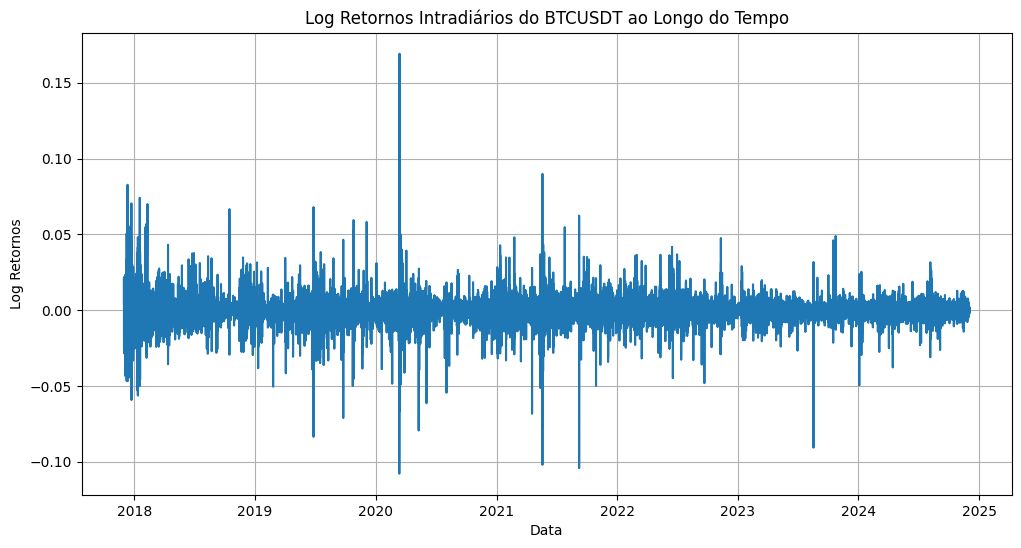

In [13]:
# Convert 'tempo' column to datetime and set it as index for plotting
# Use format='mixed' to handle the mixed date and time formats
df['tempo'] = pd.to_datetime(df['tempo'], format='mixed')
df_indexed = df.set_index('tempo')

# Plot the log returns using the datetime index
plt.figure(figsize=(12, 6))
plt.plot(df_indexed['log_returns'])
plt.title('Log Retornos Intradiários do BTCUSDT ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Log Retornos')
plt.grid(True)
plt.show()

Estatísticas Descritivas dos Log Retornos Intradiários:
count    7.352640e+05
mean     3.148950e-06
std      2.435468e-03
min     -1.078678e-01
25%     -8.016139e-04
50%      3.865374e-07
75%      8.182784e-04
max      1.691421e-01
Name: log_returns, dtype: float64
Assimetria (Skewness): 0.0986
Curtose (Kurtosis): 111.1283


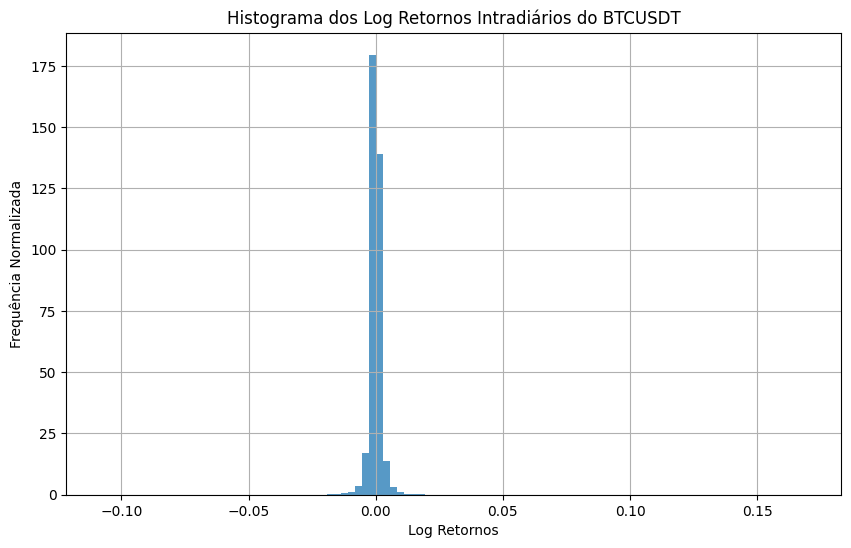

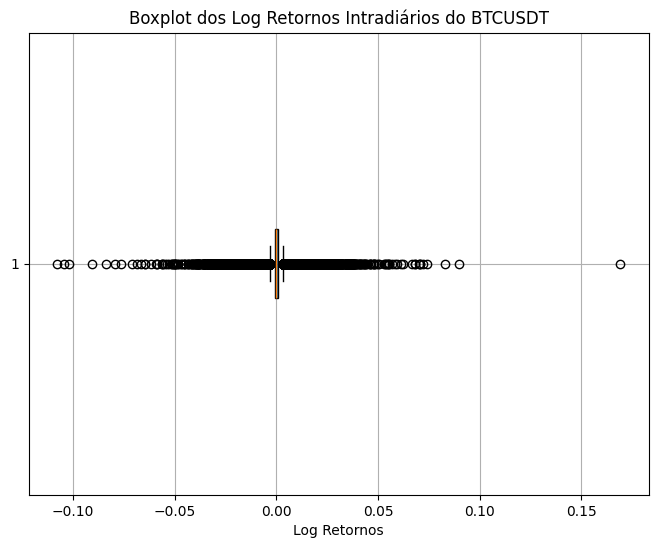

In [14]:
# Calculate descriptive statistics, including skewness and kurtosis
descriptive_stats = df['log_returns'].describe()
skewness = df['log_returns'].skew()
kurtosis = df['log_returns'].kurtosis()

print("Estatísticas Descritivas dos Log Retornos Intradiários:")
print(descriptive_stats)
print(f"Assimetria (Skewness): {skewness:.4f}")
print(f"Curtose (Kurtosis): {kurtosis:.4f}")

# Plot histogram of log returns
plt.figure(figsize=(10, 6))
plt.hist(df['log_returns'].dropna(), bins=100, density=True, alpha=0.75)
plt.title('Histograma dos Log Retornos Intradiários do BTCUSDT')
plt.xlabel('Log Retornos')
plt.ylabel('Frequência Normalizada')
plt.grid(True)
plt.show()

# Plot boxplot of log returns
plt.figure(figsize=(8, 6))
plt.boxplot(df['log_returns'].dropna(), vert=False, patch_artist=True)
plt.title('Boxplot dos Log Retornos Intradiários do BTCUSDT')
plt.xlabel('Log Retornos')
plt.grid(True)
plt.show()

In [15]:
# Ensure the 'tempo' column is datetime and set it as index if not already
if not isinstance(df.index, pd.DatetimeIndex):
    df['tempo'] = pd.to_datetime(df['tempo'], format='mixed')
    df_indexed = df.set_index('tempo')
else:
    df_indexed = df

# Calculate squared log returns
df_indexed['squared_log_returns'] = df_indexed['log_returns']**2

# Calculate daily realized variance by summing squared log returns per day
daily_realized_variance = df_indexed.groupby(df_indexed.index.date)['squared_log_returns'].sum()

print("Série Diária da Variância Realizada do BTC:")
display(daily_realized_variance.head())

Série Diária da Variância Realizada do BTC:


2017-11-30    0.015517
2017-12-01    0.005728
2017-12-02    0.003080
2017-12-03    0.009681
2017-12-04    0.004307
Name: squared_log_returns, dtype: float64

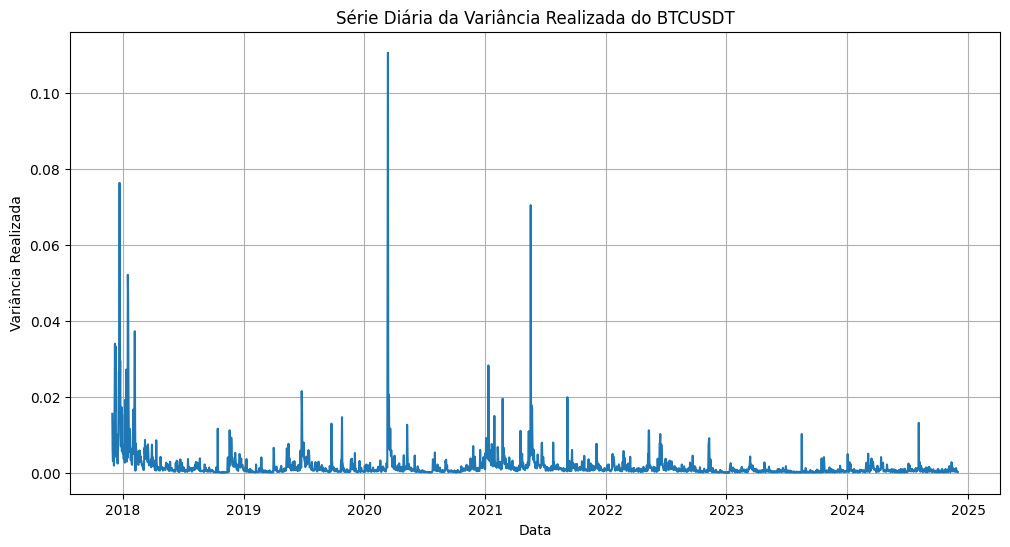


Estatísticas Descritivas da Variância Realizada Diária:
count    2559.000000
mean        0.001704
std         0.004359
min         0.000008
25%         0.000376
50%         0.000728
75%         0.001542
max         0.110556
Name: squared_log_returns, dtype: float64
Assimetria (Skewness) da Variância Realizada: 12.5459
Curtose (Kurtosis) da Variância Realizada: 231.6744


In [16]:
# Plot the daily realized variance
plt.figure(figsize=(12, 6))
plt.plot(daily_realized_variance)
plt.title('Série Diária da Variância Realizada do BTCUSDT')
plt.xlabel('Data')
plt.ylabel('Variância Realizada')
plt.grid(True)
plt.show()

# Calculate and print descriptive statistics for daily realized variance
print("\nEstatísticas Descritivas da Variância Realizada Diária:")
print(daily_realized_variance.describe())
print(f"Assimetria (Skewness) da Variância Realizada: {daily_realized_variance.skew():.4f}")
print(f"Curtose (Kurtosis) da Variância Realizada: {daily_realized_variance.kurtosis():.4f}")

In [17]:
import statsmodels.api as sm # Import statsmodels for add_constant

# Ensure daily_realized_variance is available and has a DatetimeIndex
# The variable daily_realized_variance is already created and indexed by date
# in the previous cell, so we can proceed directly.

print("Preparing data for simple HAR model...")

# Create a DataFrame with the daily realized variance
df_har = pd.DataFrame({'Vol': daily_realized_variance})

# Calculate lagged daily realized variance (Vol_lag_1)
df_har['Vol_lag_1'] = df_har['Vol'].shift(1)

# Calculate lagged weekly realized variance (Vol_week_mean)
# Use a rolling window of 5 (weekly) and then shift by 1
df_har['Vol_week_mean'] = df_har['Vol'].rolling(window=5, min_periods=1).mean().shift(1)

# Calculate lagged monthly realized variance (Vol_month_mean)
# Use a rolling window of 22 (monthly) and then shift by 1
df_har['Vol_month_mean'] = df_har['Vol'].rolling(window=22, min_periods=1).mean().shift(1)

# Drop rows with NaN values introduced by lags
df_har_aligned = df_har.dropna().copy()

print("Data preparation complete. Aligned DataFrame head for HAR model:")
display(df_har_aligned.head())
print("\nAligned DataFrame shape for HAR model:", df_har_aligned.shape)

# Define y and X for the HAR model estimation
# Use log(Vol) as dependent variable for consistency with MS-HAR if log was used there
# Let's check the use_log_y variable from the MS-HAR preparation
# Assuming use_log_y is not defined, we will use the original Vol for HAR as well
# If you intend to use log(Vol), define use_log_y = True before this cell
# For now, using Vol directly as per the original intention before the log check

df_har_aligned['y_har'] = df_har_aligned['Vol']
print("\nUsing Vol as dependent variable for HAR model.")


X_har_cols = ['Vol_lag_1', 'Vol_week_mean', 'Vol_month_mean']
X_har_df = df_har_aligned[X_har_cols]

# Add a constant to the design matrix X
X_har_df = sm.add_constant(X_har_df)

# Convert to numpy arrays for estimation
y_har_arr = df_har_aligned['y_har'].values
X_har_arr = X_har_df.values

print("\nVariables y_har and X_har prepared for HAR model estimation.")
print("Shape of y_har_arr:", y_har_arr.shape)
print("Shape of X_har_arr:", X_har_arr.shape)

Preparing data for simple HAR model...
Data preparation complete. Aligned DataFrame head for HAR model:


,Vol,Vol_lag_1,Vol_week_mean,Vol_month_mean
2017-12-01,0.005728,0.015517,0.015517,0.015517
2017-12-02,0.003080,0.005728,0.010622,0.010622
2017-12-03,0.009681,0.003080,0.008108,0.008108
2017-12-04,0.004307,0.009681,0.008501,0.008501
2017-12-05,0.001879,0.004307,0.007663,0.007663



Aligned DataFrame shape for HAR model: (2558, 4)

Using Vol as dependent variable for HAR model.

Variables y_har and X_har prepared for HAR model estimation.
Shape of y_har_arr: (2558,)
Shape of X_har_arr: (2558, 4)


In [18]:
# Check if the necessary variables from data preparation exist
if 'y_har_arr' not in locals() or 'X_har_arr' not in locals() or 'X_har_df' not in locals():
    print("Error: Data preparation variables for HAR model not found. Please run the data preparation cell for the simple HAR model first.")
else:
    print("Estimating the simple HAR model...")

    # Create and fit the OLS model
    har_model = sm.OLS(y_har_arr, X_har_arr)
    har_results = har_model.fit()

    # Print the model summary
    print(har_results.summary())

    print("\nSimple HAR model estimation complete.")

Estimating the simple HAR model...
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.295
Model:                            OLS   Adj. R-squared:                  0.294
Method:                 Least Squares   F-statistic:                     356.7
Date:                Fri, 10 Oct 2025   Prob (F-statistic):          1.93e-193
Time:                        21:13:05   Log-Likelihood:                 10727.
No. Observations:                2558   AIC:                        -2.145e+04
Df Residuals:                    2554   BIC:                        -2.142e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.